In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve


In [2]:
processed_dir = Path("../data/processed")
figures_dir = Path("../figures")
results_dir = Path("../results")

figures_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)


In [3]:
heart_final = pd.read_csv(processed_dir / "heart_final.csv")
heart_final.head()


,age,trestbps,chol,thalch,oldpeak,sex_female,sex_male,dataset_cleveland,dataset_hungary,dataset_switzerland,...,slope_flat,slope_upsloping,thal_fixed defect,thal_normal,thal_reversable defect,fbs,exang,ca,target,split
0,0.907937,0.177313,0.907926,-0.295985,0.163836,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1,train
1,-0.045332,-0.206034,0.160533,-0.894460,-0.810968,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0,train
2,-0.257170,-0.096506,-1.832512,1.020660,-0.810968,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,train
3,-0.574926,-0.644144,0.787974,-0.694968,-0.810968,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,train
4,0.272424,-0.096506,-0.134733,-1.492935,-0.810968,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,train


In [4]:
train_data = heart_final[heart_final["split"] == "train"].copy()
test_data = heart_final[heart_final["split"] == "test"].copy()

X_train = train_data.drop(columns=["target", "split"])
y_train = train_data["target"]

X_test = test_data.drop(columns=["target", "split"])
y_test = test_data["target"]

X_train.shape, X_test.shape


((736, 27), (184, 27))

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
k_values = range(1, 21)
cv_results = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    cv_results.append({
        "k": k,
        "cv_accuracy_mean": scores.mean(),
        "cv_accuracy_std": scores.std()
    })

cv_results = pd.DataFrame(cv_results)
cv_results


,k,cv_accuracy_mean,cv_accuracy_std
0,1,0.775786,0.040274
1,2,0.759533,0.034942
2,3,0.816547,0.023367
3,4,0.835558,0.030109
4,5,0.827432,0.021442
5,6,0.831504,0.028111
6,7,0.850561,0.028110
7,8,0.834262,0.036542
8,9,0.842425,0.028448
9,10,0.835604,0.029582


In [6]:
best_k = int(cv_results.sort_values("cv_accuracy_mean", ascending=False).iloc[0]["k"])
best_cv_mean = cv_results.loc[cv_results["k"] == best_k, "cv_accuracy_mean"].iloc[0]
best_cv_std = cv_results.loc[cv_results["k"] == best_k, "cv_accuracy_std"].iloc[0]

best_k, best_cv_mean, best_cv_std


(7, np.float64(0.8505607648464792), np.float64(0.028109710921155082))

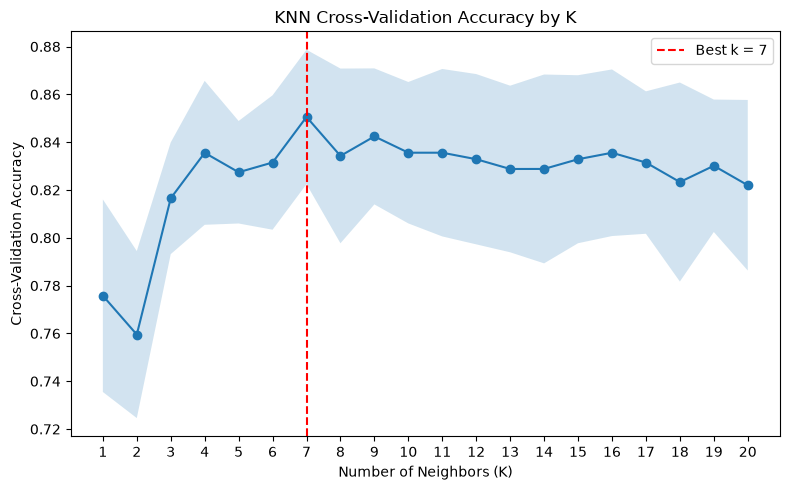

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(cv_results["k"], cv_results["cv_accuracy_mean"], marker="o")
plt.fill_between(
    cv_results["k"],
    cv_results["cv_accuracy_mean"] - cv_results["cv_accuracy_std"],
    cv_results["cv_accuracy_mean"] + cv_results["cv_accuracy_std"],
    alpha=0.2
)
plt.axvline(best_k, color="red", linestyle="--", label=f"Best k = {best_k}")
plt.title("KNN Cross-Validation Accuracy by K")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Cross-Validation Accuracy")
plt.xticks(list(k_values))
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "knn_accuracy_vs_k.png", dpi=300)
plt.show()


In [8]:
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train, y_train)

y_pred = knn_model.predict(X_test)
y_proba = knn_model.predict_proba(X_test)[:, 1]


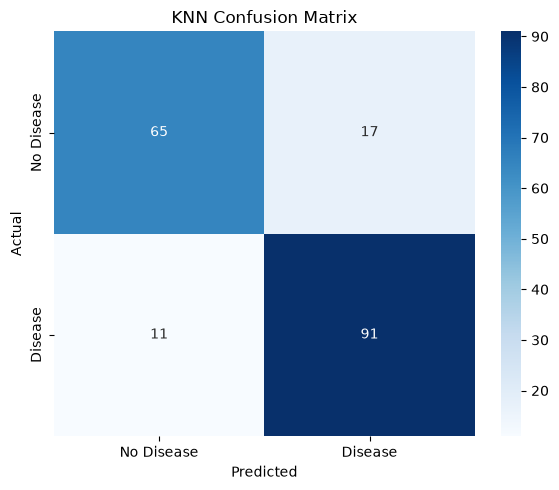

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Disease", "Disease"], yticklabels=["No Disease", "Disease"])
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(figures_dir / "confusion_matrix_knn.png", dpi=300)
plt.show()


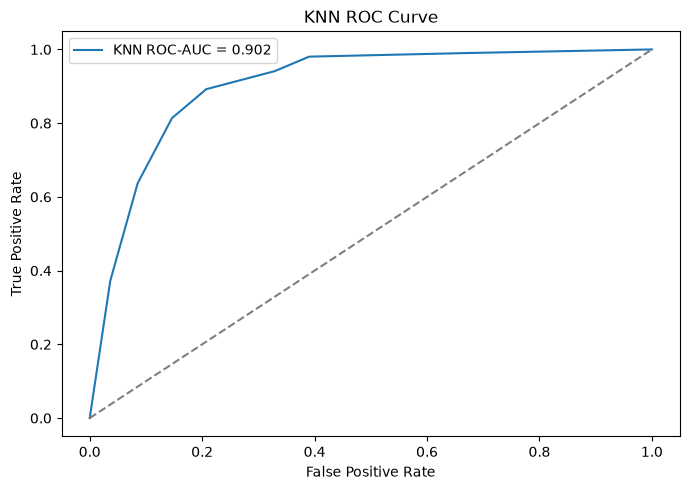

In [10]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"KNN ROC-AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("KNN ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "roc_curve_knn.png", dpi=300)
plt.show()


In [11]:
knn_metrics = pd.DataFrame([{
    "model": "KNN",
    "best_k": best_k,
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": auc_score,
    "cv_mean": best_cv_mean,
    "cv_std": best_cv_std
}])

knn_metrics


,model,best_k,accuracy,precision,recall,f1,roc_auc,cv_mean,cv_std
0,KNN,7,0.847826,0.842593,0.892157,0.866667,0.90208,0.850561,0.02811


In [12]:
knn_metrics.to_csv(results_dir / "knn_metrics.csv", index=False)
cv_results.to_csv(results_dir / "knn_cv_results.csv", index=False)
